In [1]:
import numpy as np
import samplers as samplers
import matplotlib.pyplot as plt
import time
import arviz as az

lambda  0.006998327356004832 , beta  5.0


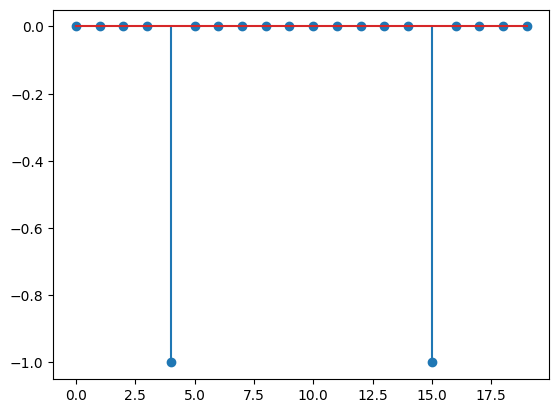

In [2]:
p = 20 #signal dimension
m = 50 #number of measurements

#make x0 sparse
x0 = np.sign(np.random.randn(p,))
x0[np.random.permutation(p)[:9*p//10] ]=np.zeros(9*p//10,)
plt.stem(x0)

A = np.random.randn(m,p)/np.sqrt(m)/4
# A = np.array([[1,2]]).T
# print(A)
y = A@x0

lam = np.max(np.abs(A.T@y))*.1
# lam = .5
beta = 5.

print('lambda ', lam, ', beta ', beta)

#smooth part of log density and its gradient
fval = lambda x: np.linalg.norm(A@x - y)**2 * 0.5
grad = lambda x: A.T@(A@x - y)

In [3]:
def compute_ess(samples):
    ess = az.ess(samples)
    return np.mean(ess)

def run_experiment(run_sampler_fn, init, n, burn_in):
    t0 = time.time()
    samples = run_sampler_fn(init, n, burn_in)
    runtime = time.time() - t0
    
    ess = compute_ess(samples)
    ess_per_sec = ess / runtime
    
    return runtime, ess, ess_per_sec

### Proximal Langevin

In [4]:
#Lipschitz constant of smooth part
Lf = np.linalg.norm(A.T@A, 2)

#parameter for moreau envelope regularization
gamma= 1/Lf/5
# gamma= 1/Lf/100

#stepsize
tau = gamma/5/(Lf*gamma+1)
print(tau)

# We will record the results in the following lists
method_list = []
sample_list = []
time_list = []


#number of samples and burn in
n_exp = 5
m_exp = 4
n = 10**n_exp #number of samples  to generate
burn_in = 10**m_exp #number of burn in samples

0.20988481674670584


In [5]:
#defined the gradient of  Moreau-envelope of the density
def soft(x,tau):
    return np.sign(x)*np.maximum(np.abs(x)-tau,0)
grad_F = lambda x:  grad(x) + (x - soft(x,lam*gamma))/gamma

#Run proximal langevin
name = 'Prox-l1'
Iterate = lambda x: samplers.one_step_langevin(x,p, grad_F, tau,beta)
xinit = np.random.randn(p,)

t1 = time.time()
samples_proxl1 = samplers.generate_samples_x(Iterate, xinit, n, burn_in)
time_list.append(time.time()-t1)

method_list.append(name)
sample_list.append(samples_proxl1)

### Hadamard Langevin

In [6]:
n = 10**n_exp #number of samples  to generate
burn_in = 10**m_exp #number of burn in samples

#we will use the same stepsize as for proximal langevin
name = 'Hadamard'
Iterate = lambda x: samplers.one_step_hadamard(x, p,grad, tau, lam,beta)

#initialization
uinit = np.random.rand(p,)
vinit = np.random.randn(p,)
uvinit = np.concatenate((uinit,vinit))

t1 = time.time()
samples_uv = samplers.generate_samples_x(Iterate, uvinit, n, burn_in)

#take the Hadamard product for samples to the required density
samples_x_uv = samples_uv[:,:p]*samples_uv[:,p:]

time_list.append(time.time()-t1)


method_list.append(name)

sample_list.append(samples_x_uv)

### Running the Gibbs sampler

In [7]:
name = 'Gibbs'
n = 10**(n_exp-1) #number of samples  to generate
burn_in = 10**(m_exp-3) #number of burn in samples

init = np.ones(p,)
t1 = time.time()
gibbs_x_samples = samplers.gibbs_sampler(A,y, lam,init, n, burn_in=burn_in, beta=beta)
# gibbs_x_samples = gibbs_samples[:,:p]
time_list.append(time.time()-t1)


method_list.append(name)
sample_list.append(gibbs_x_samples)

### Visualize the results

Prox-l1


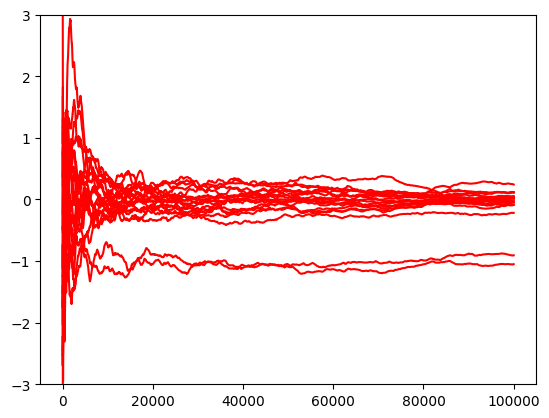

Hadamard


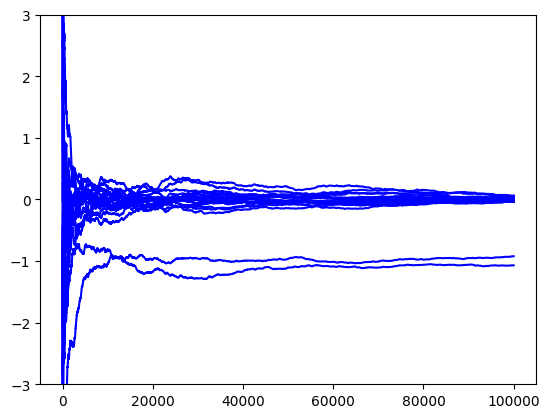

Gibbs


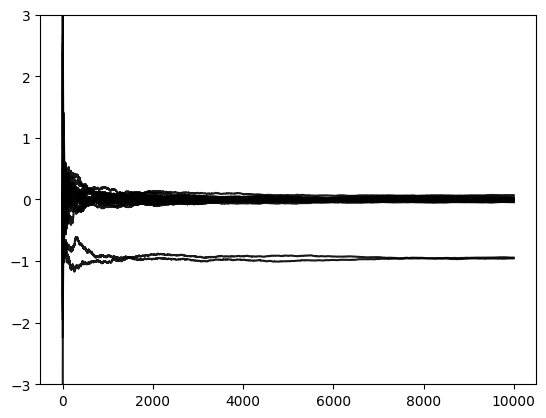

In [8]:
# Plot the running means
M = len(method_list)

from itertools import cycle

colours = cycle(['red', 'blue', 'black'])

# mean_true = integrate.quad(lambda x: x**2*f(x), -np.inf, np.inf)[0]/Total_mass

for i in range(M):
    samples = sample_list[i]
    name = method_list[i]
    running_mean = np.cumsum(samples, axis=0) / (np.arange(len(samples))[:, None] + 1)
    c = next(colours)
    print(name)
    if i<M-1:
        plt.plot(running_mean,color = c,label=name,alpha=1)
    else:
        plt.plot(running_mean,color = c,label=name,alpha=.9)
    plt.ylim([-3,3])
    plt.savefig(name+'means.pdf', bbox_inches='tight')
    plt.show()

### Check the effective sample size

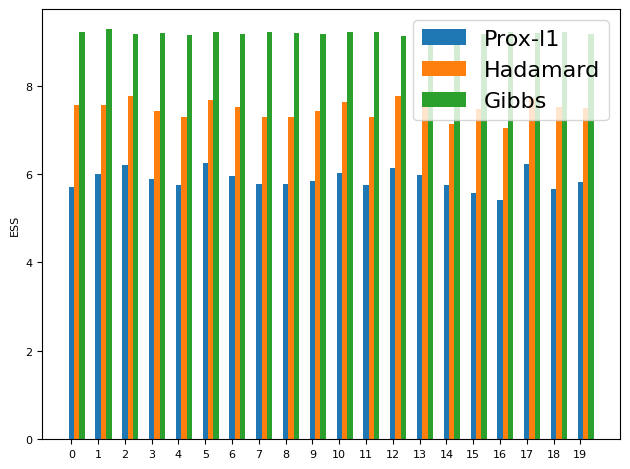

Prox-l1
5.40568855453886
Hadamard
7.044494906887079
Gibbs
9.113630679857469


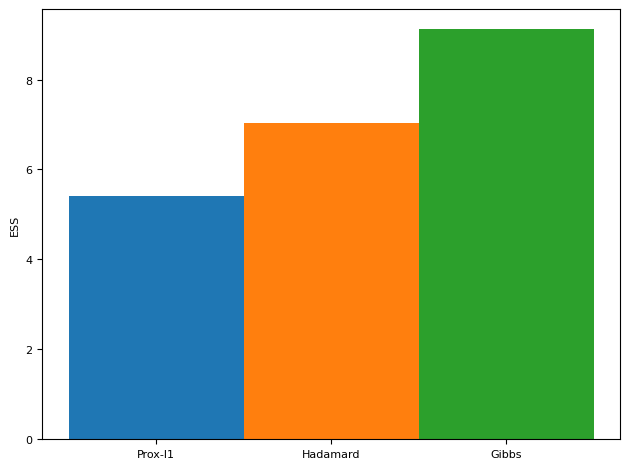

In [9]:
# Compute Effective Sample Size (ESS)

idata_list = []
ess_list= []
ess_per_second_list = []
for samples in sample_list:

    idata = az.convert_to_inference_data(np.expand_dims(samples, 0))
    idata_list.append(idata)
    ess_list.append(az.ess(idata))

# Visualization
labels = [str(i) for i in range(p)]

fig, ax = plt.subplots()

M = len(method_list)
width = 0.2  # the width of the bars

x = np.arange(p)-width
for i in range(M):
    ess_values = np.log(ess_list[i]['x'].values)
    rects1 = ax.bar(x +i*width, ess_values, width, label=method_list[i])


# # Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('ESS',fontsize=8)
# ax.set_title('Effective Sample Size by Algorithm and dimension')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=16)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

fig.tight_layout()
plt.savefig('ESS.pdf', bbox_inches='tight')
# plt.xlabel('Dimension')
plt.show()

#display minimum ess
# Visualization
if p>1:
    labels = [str(i) for i in range(p)]

    fig, ax = plt.subplots()

    M = len(method_list)
    width = 0.2  # the width of the bars

    x = np.arange(1)-width
    xticks=[]
    for i in range(M):
        print(method_list[i])
        ess_values = np.log((ess_list[i]['x'].values).min())
        print(ess_values)
        rects1 = ax.bar(x +i*width, ess_values, width, label=method_list[i])
        xticks.append(x[0] +i*width)

    ax.set_ylabel('ESS',fontsize=8)
    # ax.set_title('Minimum Effective Sample Size by Algorithm')
    ax.set_xticks(xticks)
    ax.set_xticklabels(method_list,fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    fig.tight_layout()
    plt.savefig('ESS_min.pdf', bbox_inches='tight')

    # plt.xlabel('Dimension')
    plt.show()

lambda  0.005483227095131833 , beta  5.0
lambda  0.005363494654385507 , beta  5.0
lambda  0.0077838639603090495 , beta  5.0
lambda  0.013578270073154536 , beta  5.0
lambda  0.006954164303033222 , beta  5.0
lambda  0.009736746652577845 , beta  5.0
lambda  0.0071607206380922776 , beta  5.0


/Users/triptesh_b/Downloads/Coursework/Research Skills/Group Project/rscam-mcmc-nonsmooth-sampling/samplers.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  eta[j]= 1/invgauss.rvs(mu=abs(1./(beta*lam*np.abs(x[j]))), scale=(lam*beta)**2)


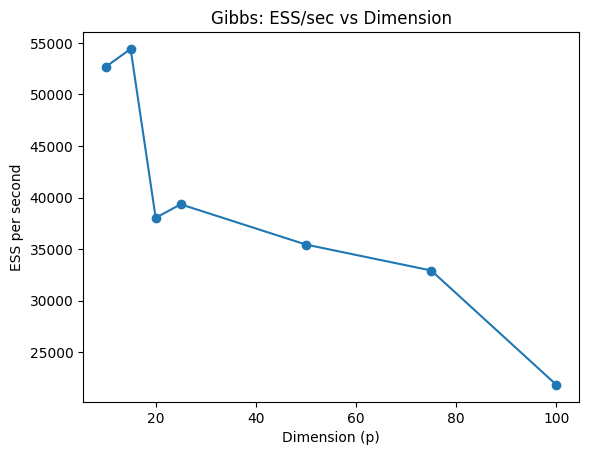

In [24]:
p_list = [10, 15, 20, 25, 50, 75, 100] #signal dimension
m_list = [20, 30, 40, 50, 100, 150, 200] #number of measurements

ess_per_sec_list = []

for i in range(len(p_list)):
    p = p_list[i]
    m = m_list[i]
    n = 10**(n_exp-1) 
    burn_in = 10**(m_exp-3) 

    x0 = np.sign(np.random.randn(p,))
    x0[np.random.permutation(p)[:9*p//10] ]=np.zeros(9*p//10,)
    
    A = np.random.randn(m,p)/np.sqrt(m)/4
    y = A@x0
    
    lam = np.max(np.abs(A.T@y))*.1
    beta = 5.
    
    print('lambda ', lam, ', beta ', beta)
    
    init = np.ones(p,)

    t0 = time.time()
    samples = samplers.gibbs_sampler(A, y, lam, init, n, burn_in=burn_in, beta=beta)
    runtime = time.time() - t0

    ess = compute_ess(samples)
    ess_per_sec_list.append(ess/runtime)


plt.plot(p_list, ess_per_sec_list, marker='o')
plt.xlabel("Dimension (p)")
plt.ylabel("ESS per second")
plt.title("Gibbs: ESS/sec vs Dimension")
plt.show()

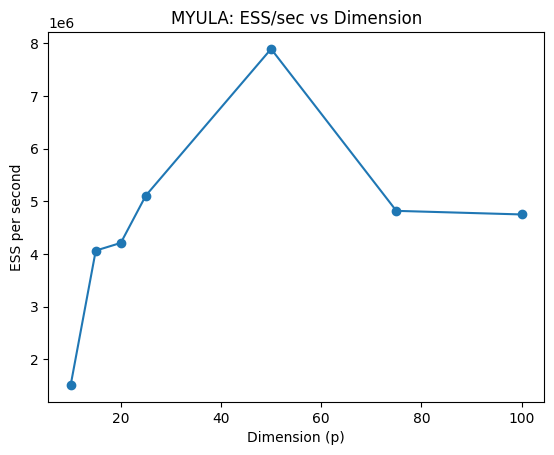

In [28]:
p_list = [10, 15, 20, 25, 50, 75, 100] #signal dimension
m_list = [20, 30, 40, 50, 100, 150, 200] #number of measurements

ess_per_sec_list = []

for i in range(len(p_list)):
    p = p_list[i]
    m = m_list[i]
    n = 10**(n_exp-1) 
    burn_in = 10**(m_exp-3) 

    x0 = np.sign(np.random.randn(p,))
    x0[np.random.permutation(p)[:9*p//10] ]=np.zeros(9*p//10,)
    
    A = np.random.randn(m,p)/np.sqrt(m)/4
    y = A@x0
    
    def soft(x,tau):
        return np.sign(x)*np.maximum(np.abs(x)-tau,0)
    
    grad_F = lambda x:  grad(x) + (x - soft(x,lam*gamma))/gamma

    t0 = time.time()
    Iterate = lambda x: samplers.one_step_langevin(x,p, grad_F, tau,beta)
    xinit = np.random.randn(p,)
    
    samples_proxl1 = samplers.generate_samples_x(Iterate, xinit, n, burn_in)
    runtime = time.time()-t0

    ess = compute_ess(samples_proxl1)
    ess_per_sec_list.append(ess/runtime)


plt.plot(p_list, ess_per_sec_list, marker='o')
plt.xlabel("Dimension (p)")
plt.ylabel("ESS per second")
plt.title("MYULA: ESS/sec vs Dimension")
plt.show()

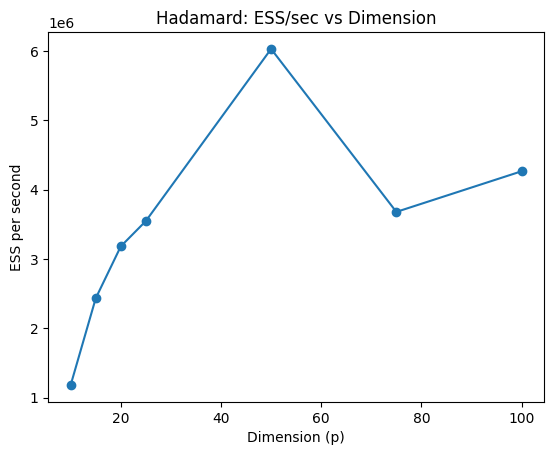

In [31]:
p_list = [10, 15, 20, 25, 50, 75, 100] #signal dimension
m_list = [20, 30, 40, 50, 100, 150, 200] #number of measurements

ess_per_sec_list = []

for i in range(len(p_list)):
    p = p_list[i]
    m = m_list[i]
    n = 10**(n_exp-1) 
    burn_in = 10**(m_exp-3) 

    x0 = np.sign(np.random.randn(p,))
    x0[np.random.permutation(p)[:9*p//10] ]=np.zeros(9*p//10,)
    
    A = np.random.randn(m,p)/np.sqrt(m)/4
    y = A@x0
    
    Iterate = lambda x: samplers.one_step_hadamard(x, p,grad, tau, lam,beta)

    uinit = np.random.rand(p,)
    vinit = np.random.randn(p,)
    uvinit = np.concatenate((uinit,vinit))
    
    t0 = time.time()
    samples_uv = samplers.generate_samples_x(Iterate, uvinit, n, burn_in)
    runtime = t0 - time.time()
    
    #take the Hadamard product for samples to the required density
    samples_x_uv = samples_uv[:,:p]*samples_uv[:,p:]
    
    runtime = time.time()-t0

    ess = compute_ess(samples_x_uv)
    ess_per_sec_list.append(ess/runtime)


plt.plot(p_list, ess_per_sec_list, marker='o')
plt.xlabel("Dimension (p)")
plt.ylabel("ESS per second")
plt.title("Hadamard: ESS/sec vs Dimension")
plt.show()